In [28]:
import rioxarray
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
#plt.title=plt.title.__globals__['title']

xr.set_options(keep_attrs=True, display_expand_data=False)

### Loading the georeferenced raster data
- rioxarray loads georeferenced raster data including its crs and geospatial transformations

In [29]:
#url='https://github.com/opengeos/datasets/releases/download/raster/LC09_039035_20240708_90m.tif'
url='data/input_raster.tif'
data=rioxarray.open_rasterio(url)
data

<xarray.DataArray (band: 7, y: 522, x: 514)> Size: 8MB
[1878156 values with dtype=float32]
Coordinates:
  * band         (band) int64 56B 1 2 3 4 5 6 7
  * x            (x) float64 4kB 6.447e+05 6.448e+05 ... 6.908e+05 6.909e+05
  * y            (y) float64 4kB 4.026e+06 4.026e+06 ... 3.979e+06 3.979e+06
    spatial_ref  int64 8B 0
Attributes: (12/96)
    ALGORITHM_SOURCE_SURFACE_REFLECTANCE:  LaSRC_1.6.0
    ALGORITHM_SOURCE_SURFACE_TEMPERATURE:  st_1.5.0
    AREA_OR_POINT:                         Area
    CLOUD_COVER:                           0
    CLOUD_COVER_LAND:                      0
    COLLECTION_CATEGORY:                   T1
    ...                                    ...
    WRS_PATH:                              39
    WRS_ROW:                               35
    WRS_TYPE:                              2
    _FillValue:                            -inf
    scale_factor:                          1.0
    add_offset:                            0.0

### rioxarray's open_rasterio method
 loads data to an Xarray `DataArray` 
 
 automatically attaches geospatial metadata:
- crs
- affine transformations
- spatial coordinates

### dataset inspection?

inspect its:
- dimensions - dims
- coordinates - coords &
- attributes - attrs

In [30]:
data.dims #view the structure of the DataArray

('band', 'y', 'x')

In [31]:
data.coords #coordiates; geographic/projected

Coordinates:
  * band         (band) int64 56B 1 2 3 4 5 6 7
  * x            (x) float64 4kB 6.447e+05 6.448e+05 ... 6.908e+05 6.909e+05
  * y            (y) float64 4kB 4.026e+06 4.026e+06 ... 3.979e+06 3.979e+06
    spatial_ref  int64 8B 0

In [32]:
#print(data.attrs) #metadata including crs

### Checking CRS & Transformation Information

In [33]:
#check crs
data.rio.crs

CRS.from_epsg(32611)

In [34]:
#check the affine transformation - how pixel coordinates have been mapped to geographic coordinate
data.rio.transform()

Affine(90.0, 0.0, 644670.0,
       0.0, -90.0, 4025880.0)

### Affine transformation matrix params
| a  b  c |

| d  e  f |

where: 
- a & e -> scaling factors - scale a set of points up/down in x & y directions
- b & d -> rotation factors - rotates a set of points about the origin
- c & f -> translation factors - moves a set of poins a fixed distance in x & y directions

In [35]:
### when CRS is missing/incorrect, assign a crs
data=data.rio.write_crs('EPSG:32611', inplace=True)

## Basic Geospatial Operations

### 1. Reprojection
e.g., to reproject from current projection to WGS84 geographic coordinate sys(EPSG:4326)

In [36]:
#reproject to WGS84
reprojected_data=data.rio.reproject('EPSG:4326')
print(reprojected_data.rio.crs)

EPSG:4326


### 2. Clipping 

important when you are focusing on a specific geographic area
- clip dataset using a bounding box
- bbox must match dataset crs

#### 2.2 using bbox

In [37]:
#using bbox in same crs as dataset
bbox=[-115.391, 35.982, -114.988, 36.425]
clipped_data=reprojected_data.rio.clip_box(*bbox)

In [38]:
clipped_data.shape

(7, 426, 446)

#### 2.2 using a vector dataset(boundaries) with polygon geometries

In [39]:
import geopandas as gpd

#load geojson with area of interest - vegas
geojson_path='https://github.com/opengeos/datasets/releases/download/places/las_vegas_bounds_utm.geojson'
bounds=gpd.read_file(geojson_path)

#clip raster to vegas boundaries
vegas_data=reprojected_data.rio.clip(bounds.geometry, bounds.crs)

ValueError: Unsupported geometry type FeatureCollection

In [ ]:
vegas_data.shape

### Working with Spatial Dimensions
these are lat-long/x,y coordinates

operations on these include:

- resampling
- reducing
- slicing

#### 1. Resampling
from one resolution to another(e.g., 1km)

rio.resample method works for this

In [40]:
resampled_data=data.rio.reproject(data.rio.crs, resolution=(1000, 1000))

In [41]:
resampled_data.shape

(7, 47, 47)

#### 2. Slicing

##### Extracting Spatial Subsets
- done by selecting specific coordinate ranges

In [42]:
#select a subset of the data within a lat/lon range
min_x, max_x = -115.391, -114.988
min_y, max_y = 35.982, 36.425
subset = reprojected_data.sel(
    x=slice(min_x, max_x), y=slice(max_y, min_y)
)  # Slice y in reverse order
subset.shape

(7, 425, 445)

### Visualizing Georeferenced Data

- upon perfoming operations on the data, matplotlib helps visualize it
- lets plot a multi-band image using bands 4,3 & 2

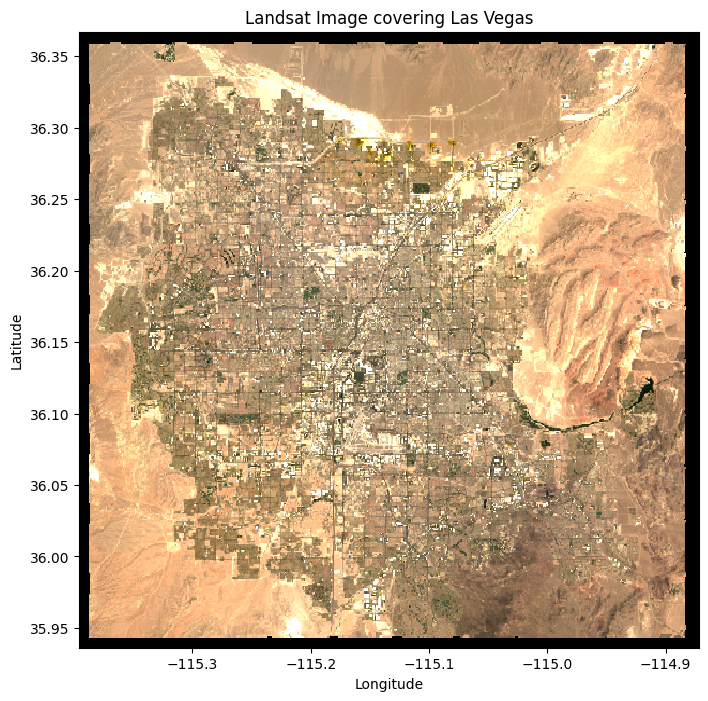

In [43]:
#plot the raster image
plt.figure(figsize=(8, 8))
reprojected_data.sel(band=[4, 3, 2]).plot.imshow(vmin=0, vmax=0.3)
plt.title("Landsat Image covering Las Vegas")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [44]:
#visualise clipped/masked data in the same way
#plot the raster image
plt.figure(figsize=(8, 8))
vegas_data.sel(band=[4, 3, 2]).plot.imshow(vmin=0, vmax=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title('Landsat Image covering Las Vegas')
plt.show()

NameError: name 'vegas_data' is not defined

<Figure size 800x800 with 0 Axes>

### Advanced plotting

to ovelay vector dataset on raster data combine :
- rioxarray
- geopandas
- matplotlib

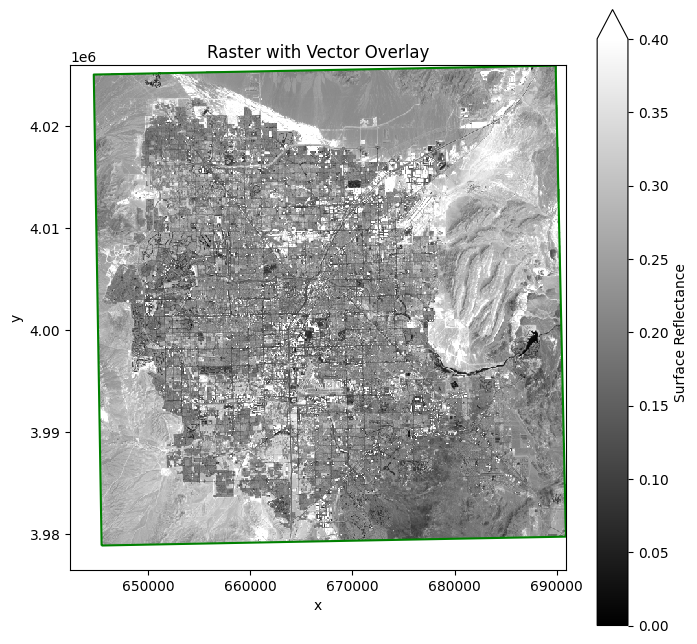

In [45]:
#plot raster with GeoJSON overlay
fig, ax =plt.subplots(figsize=(8,8))
data.attrs['long_name'] = 'Surface Reflectance' #update the long_name attribute
data.sel(band=4).plot.imshow(ax=ax, vmin=0, vmax=0.4, cmap='gray')
bounds.boundary.plot(ax=ax, color='green')
plt.title('Raster with Vector Overlay')
plt.show()

### Data Saving

rio.to_raster method saves data to disk

In [46]:
#save the data
vegas_data.rio.to_raster('data/output_raster.tif')

NameError: name 'vegas_data' is not defined

### Handling NoData Values
one can either:
- assign or
- remove(mask) NoData values

In [47]:
#assign nodata values
data2=data.rio.set_nodata(-9999)

#remove(mask) no data value
clean_data=data2.rio.write_nodata(-9999, inplace=True)


### Reproject to Multiple CRS

then compare them, e.g.,

In [48]:
#reproject to WGS84
datawgs84=data.rio.reproject('EPSG:4326')
print(datawgs84.rio.crs)

EPSG:4326


In [49]:
#reproject to web mercator
data_web_mercator=data.rio.reproject('EPSG:3857')
print(data_web_mercator.rio.crs)

EPSG:3857


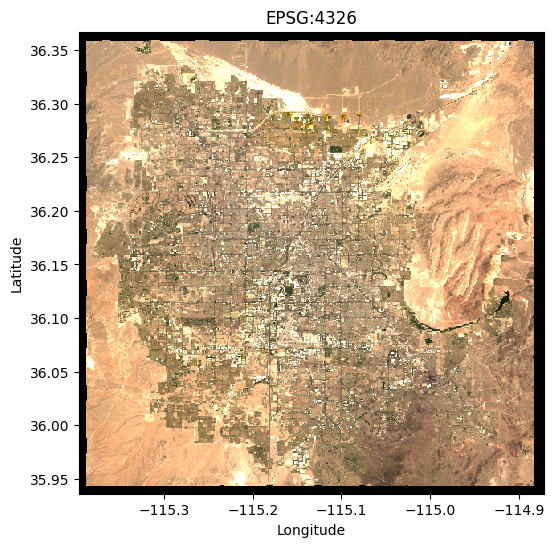

In [50]:
#plot the raster data in WGS84
plt.figure(figsize=(6, 6))
datawgs84.sel(band=[4, 3, 2]).plot.imshow(vmin=0, vmax=0.3)
plt.title("EPSG:4326")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

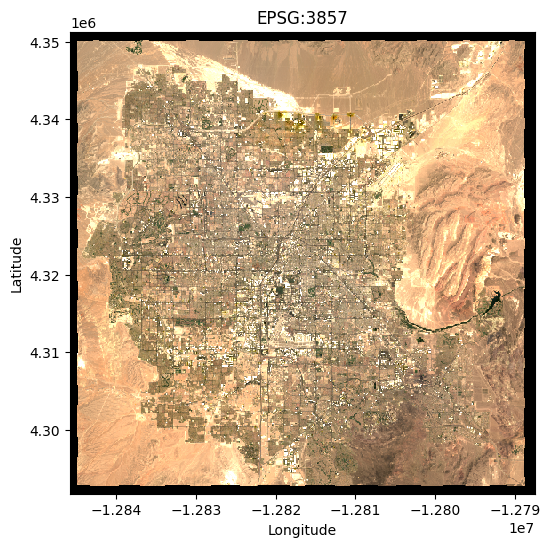

In [51]:
#plot the raster data in WGS84
plt.figure(figsize=(6, 6))
data_web_mercator.sel(band=[4, 3, 2]).plot.imshow(vmin=0, vmax=0.3)
plt.title("EPSG:3857")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Basic Band Mathematics
- Band math enables s perfome calculations across different bands
- apllication? -> NDVI calculation - an indicator of vegetation health

NDVI is calculated as:
- NDVI=(NIR-RED)/(NIR+RED)


In [52]:
#select the red(band 4) & NIR (band 5) bands
red_band=datawgs84.sel(band=4)
nir_band=datawgs84.sel(band=5)

#calculate NDVI
ndvi=(nir_band-red_band)/(nir_band+red_band)
ndvi=ndvi.clip(min=-1, max=1) #clip the values to the range [-1, 1]
ndvi.attrs['long_name'] ='NDVI'

### Plot NDVI using Matplotlib for visualization

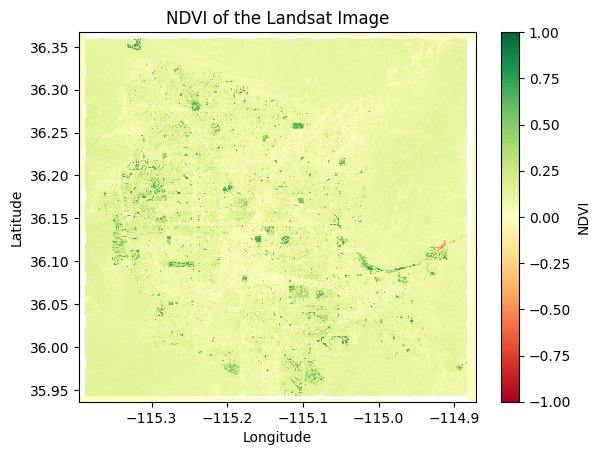

In [53]:
#lot the NDVI values
ndvi.plot(cmap="RdYlGn", vmin=-1, vmax=1)
plt.title("NDVI of the Landsat Image")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


### Mask out non-vegetated areas/areas with invalid NDVI values (e.g., water/urban areas) by appying a threshold

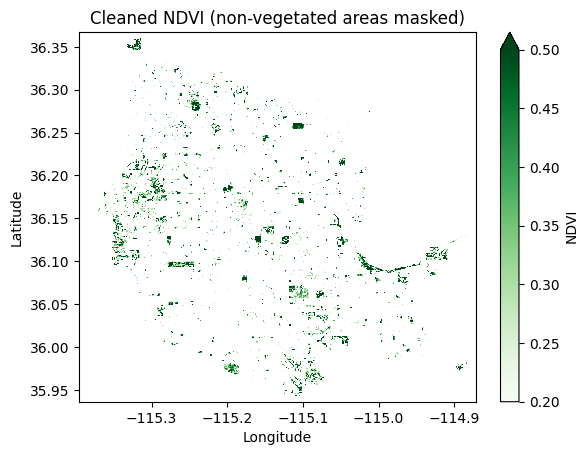

In [54]:
#mask out non-vegetated areas (NDVI)
clean_ndvi=ndvi.where(ndvi>0.25)
clean_ndvi.plot(cmap='Greens', vmin=0.2, vmax=0.5)
plt.title("Cleaned NDVI (non-vegetated areas masked)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()